<a href="https://colab.research.google.com/github/nephelim74/machinelearn/blob/main/ml_dz11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Customer ID - уникальный номер клиента
- gender - пол
- SeniorCitizen - является ли клиент пенсионером или нет (1, 0)
- Partner - имеется ли у клиента партнер (Да, Нет)
- Dependents - имеет ли клиент иждивенцев или нет (Да, Нет)
- tenure - количество месяцев, которое клиент провел в компании
- PhoneService - имеет ли клиент телефонное обслуживание или нет (Да, Нет)
- MultipleLines - имеет ли клиент несколько линий или нет (Да, Нет, Нет телефонного обслуживания)
- InternetService - поставщик услуг интернет-провайдера (DSL, оптоволокно, нет)
- OnlineSecurity - имеется ли у клиента онлайн-безопасность или нет (Да, Нет, Нет Интернет-сервис)
- OnlineBackup - прибегал ли клиент к резервному копированию в интернете (Да, Нет, Нет телефонного обслуживания)
- DeviceProtection - подключена ли у клиента защита устройства (Да, Нет, Нет телефонного обслуживания)
- TechSupport - имеется ли у клиента техническая поддержка устройства (Да, Нет, Нет телефонного обслуживания)
- StreamingTV - имеется ли у клиента онлайн трансляция телевизионных программ и видео контента через интернет (Да, Нет, Нет телефонного обслуживания)
- StreamingMovies - имеется ли у клиента сервис, который предоставляет доступ к фильмам и телевизионным шоу через интернет для просмотра на устройствах, подключенных к сети (Да, Нет, Нет телефонного обслуживания)
- Contract - срок действия контракта клиента
- PaperlessBilling - отправляет ли клиент счета и квитанции за услуги или товары электронным способом (Да, Нет, Нет телефонного обслуживания)
- PaymentMethod - способ оплаты клиента
- MonthlyCharges - ежемесячные расходы клиента
- TotalCharges - общие расходы клиента
- church - отток клиента(Да, Нет)


1. Загрузить данные и провести предварительный анализ данных
Задачи:

Загрузить данные из предоставленного источника.

Провести первичный анализ данных: изучить структуру, типы данных, пропущенные значения, распределения признаков и целевой переменной.

Визуализировать данные для лучшего понимания.

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

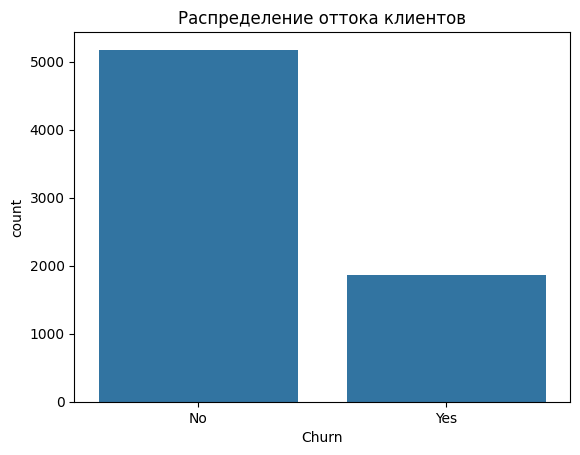

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
url = "https://raw.githubusercontent.com/shabmei/Telco-Customer-Churn/main/Telco-Customer-Churn.csv"
data = pd.read_csv(url)

# Первичный анализ
print(data.head())  # Первые 5 строк
print(data.info())  # Информация о столбцах и типах данных
print(data.describe())  # Статистика по числовым признакам

# Проверка на пропущенные значения
print(data.isnull().sum())

# Распределение целевой переменной (отток)
sns.countplot(x='Churn', data=data)
plt.title('Распределение оттока клиентов')
plt.show()

2. Подготовить данные для обучения модели
Задачи:

Удалить ненужные признаки (например, CustomerID).

Преобразовать категориальные признаки в числовые (например, с помощью One-Hot Encoding или Label Encoding).

Заполнить пропущенные значения (если есть).

Нормализовать или стандартизировать числовые признаки.

In [32]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Удаление ненужных признаков
data = data.drop('customerID', axis=1)

# Преобразование категориальных признаков
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                       'PaperlessBilling', 'PaymentMethod']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Преобразование целевой переменной
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Заполнение пропущенных значений (если есть)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# Нормализация числовых признаков
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [33]:
print(data.head())

   SeniorCitizen    tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0 -1.277445       -1.160323     -0.994242      0        False   
1              0  0.066327       -0.259629     -0.173244      0         True   
2              0 -1.236724       -0.362660     -0.959674      1         True   
3              0  0.514251       -0.746535     -0.194766      0         True   
4              0 -1.236724        0.197365     -0.940470      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                  

3. Разделить данные на обучающую и тестовую выборки
Задачи:

Разделить данные на признаки (X) и целевую переменную (y).

Разделить данные на обучающую и тестовую выборки (например, 80/20).

In [34]:
from sklearn.model_selection import train_test_split

# Разделение на признаки и целевую переменную
X = data.drop('Churn', axis=1)
y = data['Churn']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Выбрать модель машинного обучения
Задачи:

Выбрать несколько моделей для сравнения (например, логистическая регрессия, случайный лес, градиентный бустинг, SVM).

Использовать кросс-валидацию для оценки производительности моделей.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# Модели для сравнения
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC()
}

# Оценка моделей с помощью кросс-валидации
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: Средняя точность = {scores.mean():.4f}")

Logistic Regression: Средняя точность = 0.8017
Random Forest: Средняя точность = 0.7872
Gradient Boosting: Средняя точность = 0.7989
SVM: Средняя точность = 0.7975


5. Обучить модель и оценить производительность
* Обучить лучшую модель на обучающей выборке.
* Оценить производительность на тестовой выборке (точность, F1-мера, ROC-AUC).

In [36]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Список моделей для сравнения
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)  # probability=True для ROC-AUC
}

# Словарь для хранения результатов
results = {}

# Обучение и оценка каждой модели
for name, model in models.items():
    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Вероятности для ROC-AUC

    # Расчет метрик
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Сохранение результатов
    results[name] = {
        'Accuracy': accuracy,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }

    # Вывод отчета по классификации
    print(f"Модель: {name}")
    print(classification_report(y_test, y_pred))
    print("=" * 60)

# Вывод результатов
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print("-" * 40)

Модель: Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

Модель: Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Модель: Gradient Boosting
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      140

# Выводы
Лучшая точность (Accuracy):

Logistic Regression (0.8211) и SVM (0.8141) показывают наилучшую точность.

Лучший F1 Score:

Logistic Regression (0.6390) имеет наивысший F1 Score, что указывает на лучшее балансирование между precision и recall для класса 1 (отток).

Лучший ROC-AUC:

Logistic Regression (0.8622) и Gradient Boosting (0.8621) показывают наилучшие результаты по ROC-AUC, что говорит о хорошей способности разделять классы.

Общая производительность:

Logistic Regression демонстрирует стабильно высокие результаты по всем метрикам.

Gradient Boosting немного уступает по F1 Score, но близок к Logistic Regression по ROC-AUC.

SVM показывает хорошую точность, но уступает по F1 Score и ROC-AUC.

Random Forest хуже всех справляется с предсказанием оттока (низкий F1 Score и ROC-AUC).

Задачи:

Загрузить данные из предоставленного источника.

Провести первичный анализ данных: изучить структуру, типы данных, пропущенные значения, распределения признаков и целевой переменной.

Визуализировать данные для лучшего понимания.

6. Анализ результатов и важность признаков
7. Дополнительные эксперименты
#### Задачи:
Проанализировать важность признаков для лучшей модели.
Визуализировать важность признаков.
Попробовать улучшить модель с помощью подбора гиперпараметров (например, GridSearchCV или RandomizedSearchCV).
Добавить новые признаки или изменить существующие.

Поиск лучших параметров для модели: Logistic Regression
Модель: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

Лучшие параметры: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}
Поиск лучших параметров для модели: Random Forest
Модель: Random Forest
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1036
           1       0.58      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.79      0.76      1409
weighted avg       0.82      0.79      0.80      1409

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}
Поиск лучших параметров для модел

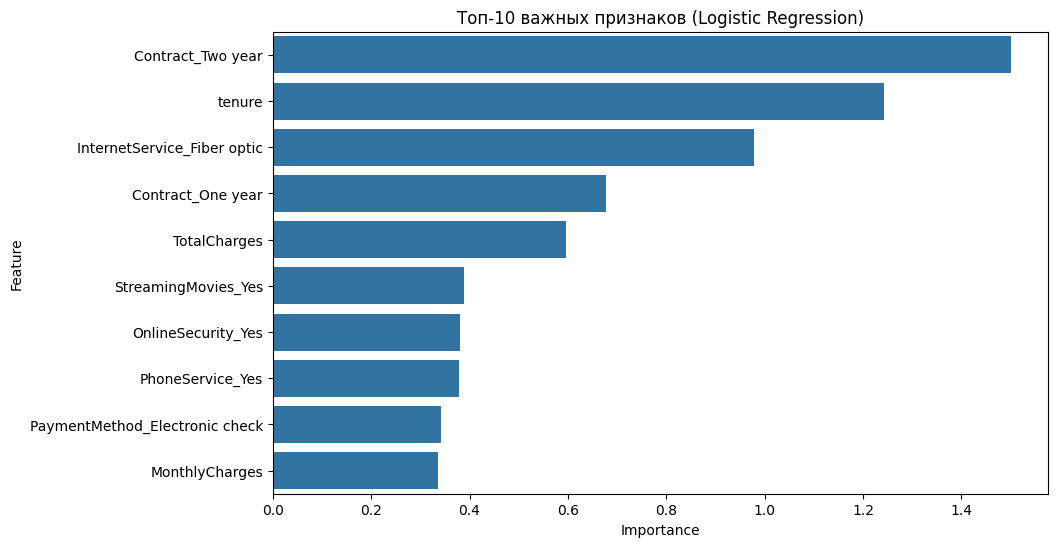

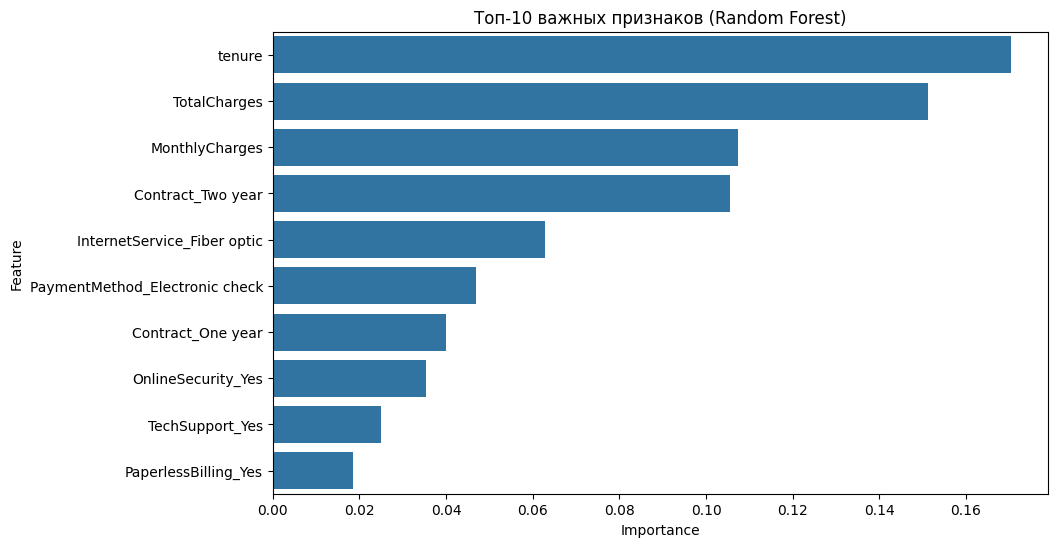

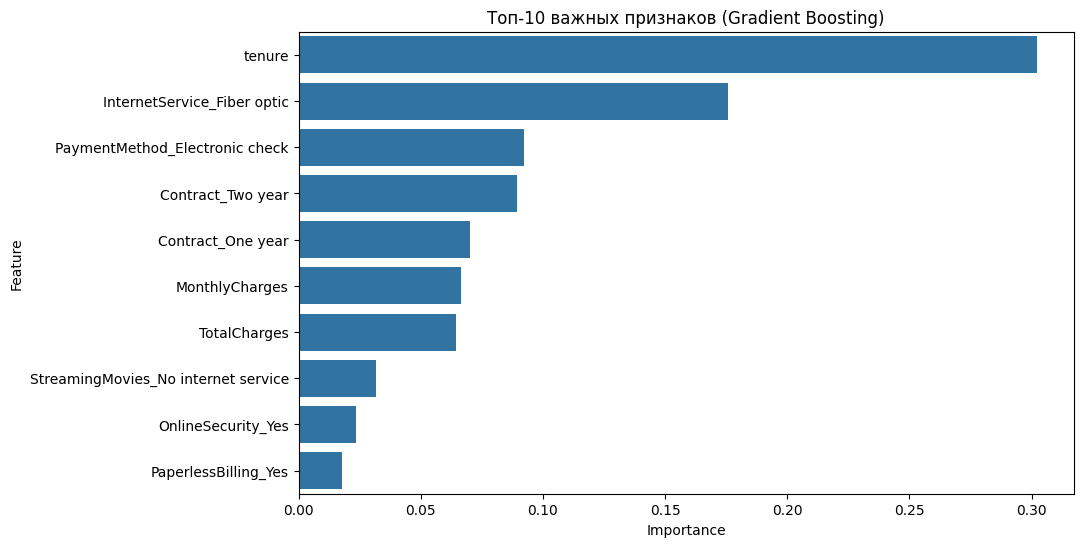

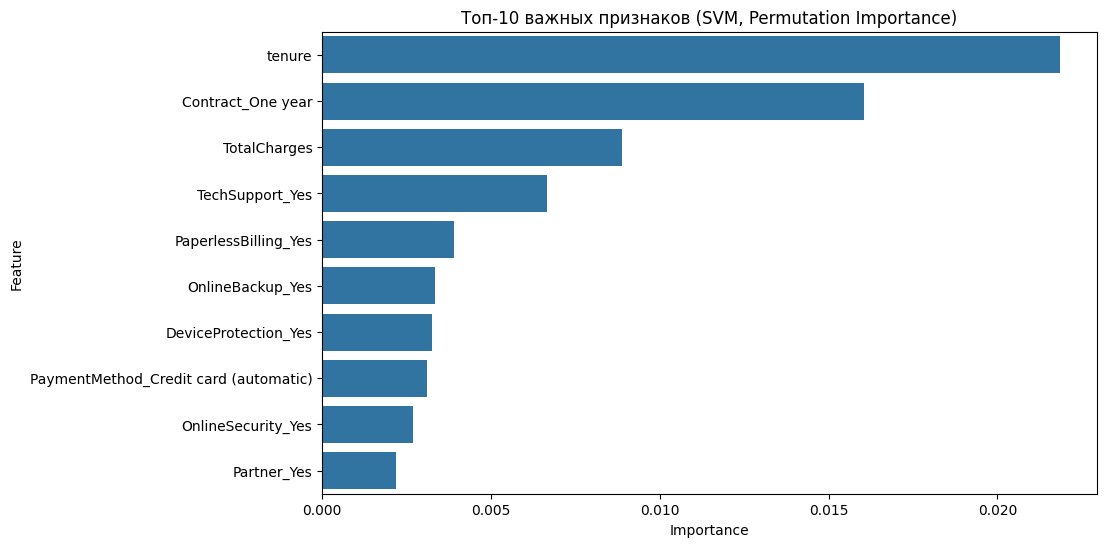

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Функция для визуализации важности признаков
def plot_feature_importance(importance_df, title):
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
    plt.title(title)
    plt.show()

# Словарь для хранения лучших моделей
best_models = {}

# Обучение и оценка улучшенных моделей
improved_results = {}

for name, config in param_grids.items():
    print(f"Поиск лучших параметров для модели: {name}")
    grid_search = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1')
    grid_search.fit(X_train, y_train)

    # Лучшая модель
    best_model = grid_search.best_estimator_
    best_models[name] = best_model  # Сохраняем лучшую модель

    # Предсказание на тестовой выборке
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Расчет метрик
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Сохранение результатов
    improved_results[name] = {
        'Accuracy': accuracy,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Best Params': grid_search.best_params_
    }

    # Вывод отчета по классификации
    print(f"Модель: {name}")
    print(classification_report(y_test, y_pred))
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print("=" * 60)

# Вывод улучшенных результатов
for model_name, metrics in improved_results.items():
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print(f"  Лучшие параметры: {metrics['Best Params']}")
    print("-" * 40)

#### Анализ важности признаков для каждой модели

#### 1. Logistic Regression
# Получение коэффициентов
coefficients = best_models['Logistic Regression'].coef_[0]
feature_importance_lr = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(coefficients)})
feature_importance_lr = feature_importance_lr.sort_values(by='Importance', ascending=False)

# Визуализация
plot_feature_importance(feature_importance_lr, 'Топ-10 важных признаков (Logistic Regression)')

#### 2. Random Forest
# Получение важности признаков
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': best_models['Random Forest'].feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Визуализация
plot_feature_importance(feature_importance_rf, 'Топ-10 важных признаков (Random Forest)')

#### 3. Gradient Boosting
# Получение важности признаков
feature_importance_gb = pd.DataFrame({'Feature': X.columns, 'Importance': best_models['Gradient Boosting'].feature_importances_})
feature_importance_gb = feature_importance_gb.sort_values(by='Importance', ascending=False)

# Визуализация
plot_feature_importance(feature_importance_gb, 'Топ-10 важных признаков (Gradient Boosting)')

#### 4. SVM
# Вычисление важности признаков с помощью Permutation Importance
result = permutation_importance(best_models['SVM'], X_test, y_test, n_repeats=10, random_state=42)
feature_importance_svm = pd.DataFrame({'Feature': X.columns, 'Importance': result.importances_mean})
feature_importance_svm = feature_importance_svm.sort_values(by='Importance', ascending=False)

# Визуализация
plot_feature_importance(feature_importance_svm, 'Топ-10 важных признаков (SVM, Permutation Importance)')

# Сравнение моделей
Метрики моделей
На основе ваших данных:

| Модель               | Accuracy | F1 Score | ROC-AUC  | Лучшие параметры                                                                 |
|----------------------|----------|----------|----------|----------------------------------------------------------------------------------|
| Logistic Regression  | 0.7502   | 0.6364   | 0.8621   | `{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}`                          |
| Random Forest        | 0.7921   | 0.6636   | 0.8647   | `{'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}`             |
| Gradient Boosting    | 0.8148   | 0.6145   | 0.8609   | `{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}`                     |
| SVM                  | 0.7587   | 0.6458   | 0.8550   | `{'C': 0.1, 'class_weight': 'balanced', 'kernel': 'rbf'}`                        |


## Анализ метрик
Accuracy:

Gradient Boosting (0.8148) показывает наивысшую точность.

Random Forest (0.7921) и SVM (0.7587) следуют за ним.

Logistic Regression (0.7502) имеет самую низкую точность.

F1 Score:

Random Forest (0.6636) имеет наивысший F1 Score, что указывает на лучшее балансирование между precision и recall.

Logistic Regression (0.6364) и SVM (0.6458) показывают схожие результаты.

Gradient Boosting (0.6145) имеет самый низкий F1 Score.

ROC-AUC:

Random Forest (0.8647) имеет наивысший ROC-AUC, что говорит о лучшей способности разделять классы.

Logistic Regression (0.8621) и Gradient Boosting (0.8609) следуют за ним.

SVM (0.8550) имеет самый низкий ROC-AUC.

## Критерии выбора лучшей модели
Производительность:

Random Forest лидирует по F1 Score и ROC-AUC, что делает его лучшим выбором для задачи предсказания оттока.

Gradient Boosting имеет наивысшую точность, но его F1 Score ниже, чем у Random Forest.

Интерпретируемость:

Logistic Regression и Random Forest легко интерпретировать.

Gradient Boosting и SVM сложнее интерпретировать, особенно SVM.

Скорость и сложность:

Logistic Regression и Random Forest быстрее обучаются и проще в настройке.

Gradient Boosting и SVM требуют больше вычислительных ресурсов и времени для обучения.

## Рекомендация
Лучшая модель: Random Forest

Причины:

Наивысший F1 Score (0.6636), что важно для задачи предсказания оттока, где важно балансировать precision и recall.

Наивысший ROC-AUC (0.8647), что указывает на хорошую способность разделять классы.

Легко интерпретировать важность признаков.

Умеренная сложность и скорость обучения.

# Общие важные признаки:

Признаки, которые важны для всех моделей (например, tenure), скорее всего, действительно сильно влияют на отток клиентов.

Уникальные важные признаки:

Признаки, которые важны только для одной или двух моделей (например, PaymentMethod_Electronic check, TechSupport_Yes),
могут быть полезны в определенных контекстах или для определенных групп клиентов.

Контекст данных:

Если данные содержат шум или мультиколлинеарность, разные модели могут по-разному интерпретировать важность признаков.

8. Сохранение модели
Задачи:

Сохранить лучшую модель в файл для использования в продакшене.
Используем файл с расширением .pkl.

In [43]:
print(best_models['Random Forest'])

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)


In [41]:
import joblib

In [42]:

# Сохранение лучшей модели (Random Forest)
joblib.dump(best_models['Random Forest'], 'best_churn_model.pkl')

['best_churn_model.pkl']

In [ ]:
import joblib
import pandas as pd

# Загрузка модели
model = joblib.load('best_churn_model.pkl')

# Новые данные (пример)
new_data = pd.DataFrame({
    'tenure': [12, 24],
    'MonthlyCharges': [70.5, 90.3],
    'TotalCharges': [850.0, 2200.0],
    'Contract_Two year': [0, 1],
    'InternetService_Fiber optic': [1, 0]
})

# Предсказание
predictions = model.predict(new_data)
probabilities = model.predict_proba(new_data)

# Вывод результатов
print("Предсказанные классы:", predictions)
print("Вероятности оттока:", probabilities[:, 1])